# Final Results

We collect here the models we have chosen for each borough thus far. Our goal here is to show the final model training, evaluation, and relevant plots. What is reproduced here can be found in the evaluations notebooks inside the folders for the boroughs and citywide level e.g. [5evaluations.ipynb](./citywide/5evaluations.ipynb) in the citywide folder.

<div style="text-align:center">

|         Level         |                                        Chosen Model                                                    |                  Folder                 |
| :-------------------: | :----------------------------------------------------------------------------------------------------: | :-------------------------------------: |
|        Citywide       |                        [Hybrid Prophet + XGBoost](./citywide/5evaluations.ipynb)                       |         [citywide](./citywide/)         |
|       Manhattan       |                         [Prophet](./manhattan/2neural_solo_prophet.ipynb)                        |        [manhattan](./manhattan/)        |
|        Brooklyn       |                              [NeuralProphet](./brooklyn/3evaluation.ipynb)                             |         [brooklyn](./brooklyn/)         |
|      Staten Island    |                         [Prophet](./staten_island/1modeling_experiments.ipynb)                         | [staten_island](./staten_island/)       |
|         Queens        | [Prophet](./bronx_and_queens/1modeling_experiments.ipynb) | [bronx_and_queens](./bronx_and_queens/)    |                                         |
|         Bronx         |                        [Prophet](./bronx_and_queens/1modeling_experiments.ipynb)                       | [bronx_and_queens](./bronx_and_queens/) |

</div>


*To improve readability and maintainability, it's better to rewrite the code using functions, instead of relying on global variables or variables defined across multiple Jupyter notebook cells. As of 2026-03-19, only the code for Brooklyn needs rewriting.

** There is some nondeterministic behavior of XGBoost and NeuralProphet that occurs here. The difference is minimal, however.

## Load Packages

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
import xgboost as xgb
import optuna
from neuralprophet import NeuralProphet
import logging
import requests


## Time Series Split

In [212]:
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

## Citywide

In [224]:
# This cell defines functions to add features for XGBoost 

def create_features(df):
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


################
## Add weather data.
# lat, lon = 40.7831, -73.9712
# start = "2020-01-01"
# end   = "2026-02-28"

# url = (
#     "https://archive-api.open-meteo.com/v1/archive"
#     f"?latitude={lat}&longitude={lon}"
#     f"&start_date={start}&end_date={end}"
#     "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
#     "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
#     "precipitation_sum,snowfall_sum"
#     "&timezone=America/New_York"
# )

# response = requests.get(url)
# data = response.json()


# wd = pd.DataFrame(data["daily"])
# wd["date"] = pd.to_datetime(wd["time"])
# wd = wd.set_index("date")


################

# nd = pd.read_csv("../scr/data/weather_data/wd_2020_to_march_2026.csv")
# wd = nd
# wd = wd.set_index('time')
# wd = nd
# wd["date"] = pd.to_datetime(wd["time"])

# def add_weather_data(df, wd):
#     df = df.copy()
#     wd = wd.copy()
#     df.index = pd.to_datetime(df.index)
#     wd.index = pd.to_datetime(wd.index)
#     if "time" in wd.columns:
#         wd = wd.drop(columns=["time"])
#     overlap = wd.columns.intersection(df.columns)
#     wd = wd.drop(columns=overlap)
#     df = df.join(wd, how="left")
#     return df

nd = pd.read_csv("../scr/data/weather_data/wd_2020_to_march_2026.csv")

# Properly set datetime index once
wd = nd.copy()
wd["time"] = pd.to_datetime(wd["time"])
wd = wd.set_index("time")

def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()

    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)

    # Remove duplicate columns
    overlap = wd.columns.intersection(df.columns)
    wd = wd.drop(columns=overlap)

    # Join on index
    df = df.join(wd, how="left")

    return df

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df


date_range = pd.date_range(start="2020-01-01", end="2026-02-28")
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())
federal_holidays = pd.DataFrame({'holiday': 'federal_us', 'ds': pd.to_datetime(holidays), 'lower_window': 0, 'upper_window': 1})

holidays = federal_holidays


def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())

    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
                
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

def add_new_lags(df, x):
    # lags
    target_map = df[x].to_dict()
    df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df[f'{x}lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df[f'{x}lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df[f'{x}lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df[f'{x}lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df[f'{x}lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df[f'{x}lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df[f'{x}lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    return df

In [225]:
# These are all of the features considered

ALL_FEATURES = {'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_temperature_min_lag21',
       'apparent_temperature_min_lag30', 'apparent_temperature_min_lag60',
       'apparent_temperature_min_lag90', 'apparent_temperature_min_lag120',
       'apparent_temperature_min_lag150', 'apparent_temperature_min_lag180',
       'apparent_temperature_min_lag210', 'apparent_temperature_min_lag240',
       'apparent_temperature_min_lag270', 'apparent_temperature_min_lag300',
       'apparent_temperature_min_lag330', 'apparent_temperature_min_lag360',
       'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730',
       'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
       'temperature_2m_max_lag60', 'is_federal_holiday', 'Trash_Law',
       'New_Trash_Law', 'Rat_Mitigation_Zone', 'Rat_Czar_Appointed',
       'residuals', 'residualslag15', 'residualslag16', 'residualslag17',
       'residualslag18', 'residualslag19', 'residualslag20', 'residualslag21',
       'residualslag30', 'residualslag365', 'residualslag730', 'trend',
       'yhat_lower', 'yhat_upper'}

In [226]:
def load_study(db_path, study_name, direction="minimize"):
    return optuna.create_study(
        direction=direction,
        study_name=study_name,
        storage=db_path,
        load_if_exists=True)

def extract_best_params(study):
    # Extracts the best parameters, features, hyperparameters from the study.
    best_params = study.best_params
    best_features = [f for f in ALL_FEATURES if best_params.get(f, False)]
    best_hyperparams = {k: v for k, v in best_params.items() if k not in ALL_FEATURES}

    return best_params, best_features, best_hyperparams

def extract_param_subset(hyperparams, keys):
    # return hyperparameters for use
    return {k: hyperparams[k] for k in keys if k in hyperparams}

study = load_study(db_path="sqlite:///citywide/xgbprophet_model26.db", study_name="hybrid_model_feature_parameter_search")

# Extract best parameters and hyperparameters
best_params, best_features, best_hyperparams = extract_best_params(study)

[I 2026-03-19 17:27:34,062] Using an existing study with name 'hybrid_model_feature_parameter_search' instead of creating a new one.


In [227]:
print("Best Params:", best_params)
print("\nBest RMSE:", study.best_value)
print("\nBest Features:", best_features)

# Extract prophet and xgb hyperparameters
prophet_keys = ["changepoint_prior_scale", "seasonality_prior_scale", "holidays_prior_scale"]
best_prophet_params = extract_param_subset(best_hyperparams, prophet_keys)
xgb_keys = ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'gamma', 'min_child_weight', 'reg_lambda', 'reg_alpha']
best_xgb_params = extract_param_subset(best_hyperparams, xgb_keys)

print("\nBest Prophet Parameters:")
print(best_prophet_params)

print("\nBest XGBoost Parameters:")
print(best_xgb_params)

Best Params: {'changepoint_prior_scale': 0.1476254975588991, 'seasonality_prior_scale': 0.3547339983371146, 'holidays_prior_scale': 2.274344908057226, 'n_estimators': 1916, 'max_depth': 4, 'learning_rate': 0.00198485296210223, 'subsample': 0.7100035979775448, 'colsample_bytree': 0.5770065237411632, 'gamma': 1.7585730706879485, 'min_child_weight': 8, 'reg_lambda': 1.1303130099058791, 'reg_alpha': 7.04862540806253, 'lag363': True, 'apparent_temperature_min_lag14': False, 'dayofweek_cos': False, 'is_federal_holiday': False, 'dayofyear': False, 'apparent_temperature_min_lag120': False, 'Rat_Czar_Appointed': False, 'ma365': False, 'lag30': False, 'lag730': False, 'apparent_temperature_min_lag16': True, 'residuals': False, 'residualslag15': True, 'Trash_Law': False, 'apparent_temperature_min_lag360': True, 'lag16': True, 'apparent_temperature_min_lag240': True, 'weekofyear': True, 'residualslag365': True, 'apparent_temperature_min_lag180': True, 'lag365': True, 'ma90': True, 'dayofweek': Fal

In [228]:
def load_and_preprocess_data(file_path, weather_data):
    # Load in data
    rs = pd.read_csv(file_path)
    rs['created_date'] = pd.to_datetime(rs['created_date'])

    # Filter data within the desired date range
    rs = rs[(rs['created_date'] >= '2020-01-01') & (rs['created_date'] < '2026-03-01')]

    # Group by date and count the occurrences
    rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
    rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

    # Save original dates
    save = rs['ds'].copy().values
    rs = rs.set_index('ds')
    rs.index = pd.to_datetime(rs.index)
    rs['ds'] = save

    # Feature engineering
    rs = create_features(rs)
    rs = add_cyclic(rs)
    rs = add_lags(rs)
    rs = add_seasonal_lags(rs)
    rs = add_moving_averages(rs)
    rs = add_weather_data(rs, weather_data)
    rs = add_more_weather_feature(rs)
    rs = add_federal_holidays(rs, custom_holidays=['12-31'])
    
    # Add law flags with specific start dates
    rs = add_law_flag(rs, law_name='Trash_Law', start_date='2024-03-01')
    rs = add_law_flag(rs, law_name='New_Trash_Law', start_date='2024-11-01')
    rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
    rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date='2023-04-12')

    return rs

In [218]:
rs = load_and_preprocess_data('../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv', wd)

In [219]:
FEATURES = best_features  # best_features already a global variable

In [220]:
def forward_fill_rows(df, seed_row, include_columns=None):
    df_ffilled = df.copy()
    
    if include_columns is None:
        # if no columns specified, forward-fill all
        include_columns = df_ffilled.columns.tolist()
    
    for i in range(len(df_ffilled)):
        if i == 0:
            # first row takes seed_row for included columns
            for col in include_columns:
                df_ffilled.at[df_ffilled.index[i], col] = seed_row[col]
        else:
            # subsequent rows take previous row for included columns
            for col in include_columns:
                df_ffilled.at[df_ffilled.index[i], col] = df_ffilled.at[df_ffilled.index[i-1], col]
                
    return df_ffilled

In [221]:
rs

,y,ds,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,dayofweek_sin,...,apparent_temperature_min_lag365,apparent_temperature_min_lag730,temperature_2m_max_lag14,temperature_2m_max_lag30,temperature_2m_max_lag60,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,17,2020-01-01,2,1,1,2020,1,1,1,0.974928,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,40,2020-01-02,3,1,1,2020,2,2,1,0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,41,2020-01-03,4,1,1,2020,3,3,1,-0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,25,2020-01-04,5,1,1,2020,4,4,1,-0.974928,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,17,2020-01-05,6,1,1,2020,5,5,1,-0.781831,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,26,2026-02-24,1,1,2,2026,55,24,9,0.781831,...,-4.6,-11.1,-0.3,-5.2,-2.8,0,1,1,1,1
2026-02-25,30,2026-02-25,2,1,2,2026,56,25,9,0.974928,...,0.1,-6.9,3.2,-3.1,-0.8,0,1,1,1,1
2026-02-26,40,2026-02-26,3,1,2,2026,57,26,9,0.433884,...,-1.4,-4.1,0.8,-7.3,0.9,0,1,1,1,1


In [222]:
def train_and_evaluate(tscv, rs, best_prophet_params, best_xgb_params, holidays, FEATURES):
    results = []

    for i, (train_index, test_index) in enumerate(tscv.split(rs)):
        train = rs.iloc[train_index].copy()
        test = rs.iloc[test_index].copy()

        # Forward-fill test using the last row of train
        test = forward_fill_rows(test, 
                                seed_row=train.iloc[-1], 
                                include_columns=['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
                                                 'apparent_temperature_max', 'apparent_temperature_min', 
                                                 'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum'])

        # Train Prophet model
        model = Prophet(**best_prophet_params, holidays=holidays)
        model.add_country_holidays(country_name='US')
        model.fit(train)

        # Generate Prophet predictions on the training set
        train_future = model.make_future_dataframe(periods=0, freq='D')
        train_forecast = model.predict(train_future)

        # Calculate residuals
        train_residuals = train['y'].values - train_forecast['yhat'].values
        residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals})
        train['residuals'] = train_residuals

        # Add new lags and other Prophet outputs
        add_new_lags(train, 'residuals')
        train['trend'] = train_forecast['trend'].values
        train['yhat_lower'] = train_forecast['yhat_lower'].values
        train['yhat_upper'] = train_forecast['yhat_upper'].values

        # Prepare the data for XGBoost
        X_train_residuals = train[FEATURES]
        y_train_residuals = residuals_df['y']

        # Train XGBoost on residuals
        xgb_model = xgb.XGBRegressor(**best_xgb_params)
        xgb_model.fit(X_train_residuals, y_train_residuals)

        # Prepare test data
        test['residuals'] = np.nan  # Initialize residuals for the test set
        dummy = pd.concat([train, test], axis=0)
        add_new_lags(dummy, 'residuals')  # Add lags for the test set

        test = dummy.iloc[test_index].copy()  # Restore test set

        # Prophet forecast for the test set
        future = model.make_future_dataframe(periods=len(test), freq='D')
        prophet_forecast = model.predict(future)

        # Add Prophet forecast features to the test set
        test.loc[:, 'trend'] = prophet_forecast[-len(test):]['trend'].values
        test.loc[:, 'yhat_lower'] = prophet_forecast[-len(test):]['yhat_lower'].values
        test.loc[:, 'yhat_upper'] = prophet_forecast[-len(test):]['yhat_upper'].values

        # XGBoost predictions on residuals
        X_test = test[FEATURES]
        xgb_residual_preds = xgb_model.predict(X_test)

        # Combine Prophet and XGBoost predictions
        y_pred = np.round(prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds)
        y_true = test['y'].values

        # Calculate RMSE for this fold
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        results.append(rmse)  # Store the RMSE for this fold

    # Convert the results into a DataFrame
    prophet_xgb_results_df = pd.DataFrame(results, columns=["RMSE"])

    # Calculate the mean RMSE across all folds
    mean_rmse = prophet_xgb_results_df['RMSE'].mean()
    prophet_xgb_results_df.loc['mean'] = [mean_rmse]

    return prophet_xgb_results_df

In [223]:
citywide_results = train_and_evaluate(tscv, rs, best_prophet_params, best_xgb_params, holidays, FEATURES)

17:26:09 - cmdstanpy - INFO - Chain [1] start processing
17:26:09 - cmdstanpy - INFO - Chain [1] done processing
17:26:12 - cmdstanpy - INFO - Chain [1] start processing
17:26:12 - cmdstanpy - INFO - Chain [1] done processing
17:26:15 - cmdstanpy - INFO - Chain [1] start processing
17:26:15 - cmdstanpy - INFO - Chain [1] done processing
17:26:18 - cmdstanpy - INFO - Chain [1] start processing
17:26:18 - cmdstanpy - INFO - Chain [1] done processing
17:26:21 - cmdstanpy - INFO - Chain [1] start processing
17:26:22 - cmdstanpy - INFO - Chain [1] done processing
17:26:25 - cmdstanpy - INFO - Chain [1] start processing
17:26:25 - cmdstanpy - INFO - Chain [1] done processing
17:26:28 - cmdstanpy - INFO - Chain [1] start processing
17:26:29 - cmdstanpy - INFO - Chain [1] done processing
17:26:32 - cmdstanpy - INFO - Chain [1] start processing
17:26:32 - cmdstanpy - INFO - Chain [1] done processing
17:26:35 - cmdstanpy - INFO - Chain [1] start processing
17:26:35 - cmdstanpy - INFO - Chain [1]

## Manhattan

In [163]:
def run_prophet_time_series_split(borough_name: str, data_path: str, tscv) -> pd.DataFrame:
    # Read data
    rs = pd.read_csv(data_path)
    rs['created_date'] = pd.to_datetime(rs['created_date']) 

    # Filter data between 2020-01-01 and 2026-02-28
    rs = rs[(rs['created_date'] >= '2020-01-01') & (rs['created_date'] < '2026-03-01')]

    # Restrict to the specified borough
    rs = rs[rs['borough'] == borough_name]

    # Drop the column with borough
    rs = rs.drop(columns=['borough'])

    # Create a continuous date index with zero-filled values for missing dates
    rs['created_date'] = pd.to_datetime(rs['created_date'])
    start = rs['created_date'].min()
    end = rs['created_date'].max()
    rs = (rs.set_index('created_date')
          .reindex(pd.date_range(start, end, freq='D'), fill_value=0)
          .rename_axis('created_date')
          .reset_index())

    # Generate US federal holidays
    date_range = pd.date_range(start="2020-01-01", end="2026-02-28")
    calendar = USFederalHolidayCalendar()
    holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

    # Build the holidays DataFrame in the same structure as your original
    federal_holidays = pd.DataFrame({
        'holiday': 'federal_us',
        'ds': pd.to_datetime(holidays),
        'lower_window': 0,
        'upper_window': 1,
    })

    # Rename columns for Prophet model
    rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

    # Initialize TimeSeriesSplit
    results = []

    for i, (train_index, test_index) in enumerate(tscv.split(rs)):
        train = rs.iloc[train_index]
        test = rs.iloc[test_index]

        # Initialize and train Prophet model
        model = Prophet(holidays=federal_holidays)
        model.add_country_holidays(country_name='US')
        model.fit(train)

        # Make future predictions
        future = model.make_future_dataframe(periods=len(test), freq='D')
        forecast = model.predict(future)

        # Obtain predicted values and compare against the actuals
        y_pred = forecast['yhat'][-len(test):].values
        y_true = test['y'].values
        y_pred = np.round(y_pred)

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Calculate MAPE
        mape = mean_absolute_percentage_error(y_true, y_pred)

        # Append results for this fold
        results.append({'fold': i, 'rmse': rmse, 'mape': mape})

    # Convert results to a DataFrame
    prophet_results_df = pd.DataFrame(results)
    prophet_results_df.loc['mean'] = ['mean', prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

    return prophet_results_df

In [164]:
data_path = '../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv'
manhattan_results = run_prophet_time_series_split("MANHATTAN", data_path, tscv)

17:01:38 - cmdstanpy - INFO - Chain [1] start processing
17:01:38 - cmdstanpy - INFO - Chain [1] done processing
17:01:39 - cmdstanpy - INFO - Chain [1] start processing
17:01:39 - cmdstanpy - INFO - Chain [1] done processing
17:01:39 - cmdstanpy - INFO - Chain [1] start processing
17:01:39 - cmdstanpy - INFO - Chain [1] done processing
17:01:40 - cmdstanpy - INFO - Chain [1] start processing
17:01:40 - cmdstanpy - INFO - Chain [1] done processing
17:01:41 - cmdstanpy - INFO - Chain [1] start processing
17:01:41 - cmdstanpy - INFO - Chain [1] done processing
17:01:41 - cmdstanpy - INFO - Chain [1] start processing
17:01:41 - cmdstanpy - INFO - Chain [1] done processing
17:01:42 - cmdstanpy - INFO - Chain [1] start processing
17:01:42 - cmdstanpy - INFO - Chain [1] done processing
17:01:43 - cmdstanpy - INFO - Chain [1] start processing
17:01:43 - cmdstanpy - INFO - Chain [1] done processing
17:01:43 - cmdstanpy - INFO - Chain [1] start processing
17:01:44 - cmdstanpy - INFO - Chain [1]

## Brooklyn

In [165]:
np.NaN = np.nan

def load_best_params(study_name: str, storage_url: str):
    study = optuna.load_study(study_name=study_name, storage=storage_url)
    best_params = study.best_params
    best_value = study.best_value  # Optional: best objective value

    return best_params, best_value

study_name = "model_neural"
storage_url = "sqlite:///brooklyn/model_neural.db"

best_params, best_value = load_best_params(study_name, storage_url)

In [166]:
def load_rat_data(data_path: str, borough_name: str, start_date: str, end_date: str):
    # Load the rat sightings data
    rs = pd.read_csv(data_path)
    rs['created_date'] = pd.to_datetime(rs['created_date'])
    rs = rs[(rs['created_date'] >= start_date) & (rs['created_date'] < end_date)]

    # Restrict to the specified borough
    rs = rs[rs['borough'] == borough_name]

    # Drop the 'borough' column
    rs = rs.drop(columns=['borough'])

    # Rename columns for Prophet
    rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
    return rs

def load_weather_data():
    nd = pd.read_csv("../scr/data/weather_data/wd_2020_to_march_2026.csv")
    wd = nd
    wd = wd.set_index('time')
    wd = nd
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
    wd = wd[['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum', 'ds']]
    return wd

In [167]:
start_date = "2020-01-01"
end_date = "2026-02-28"

rs = load_rat_data('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv', "BROOKLYN", start_date, end_date)

In [168]:
wd = load_weather_data()

In [169]:
regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

In [170]:
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

# Merge weather data with rat sightings data
rs = rs.merge(wd[['ds'] + regressed_features], on="ds", how="left")

# Prepare lag values for regressed features
lags_for_regressed_features = {
    'apparent_temperature_max': best_params['lag_temp_max'],
    'apparent_temperature_min': best_params['lag_temp_min'],
    'snowfall_sum': best_params['lag_snowfall']}


In [171]:
# Initialize list to store results
results = []

# Loop over the splits
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    print(f"Processing fold {i + 1}")
    train = rs.iloc[train_index].copy()
    train = train.dropna(subset=["y"])

    test = rs.iloc[test_index].copy()

    # Initialize NeuralProphet model
    model = NeuralProphet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        learning_rate=best_params['learning_rate'],
        epochs=best_params['epochs'],
        n_lags=best_params['n_lags'],
        ar_reg=best_params['ar_reg'],
        accelerator="auto",  # uses GPU if available
        batch_size=best_params['batch_size']
    )

    # Add US holidays
    model = model.add_country_holidays(country_name="US")

    # Add lagged regressors
    for column in regressed_features:
        model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])

    # Train the model
    print(f"Training the model for fold {i+1}.")

    model.fit(train, progress="True")

    # Prepare future dataframe with regressors
    future = pd.concat([train[['ds', 'y'] + regressed_features], 
                        test[['ds', 'y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    
    print(f"Making predictions from model for fold {i+1}.")
    forecast = model.predict(future)

    print(f"Rounding forecast for fold {i+1}.")
    # Evaluate the model
    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test["y"].values


    print(f"Evaluating forecast for fold {i+1}.")
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    # Append the results for this fold
    print(f"Appending results for fold {i+1}.")
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert results to a DataFrame
neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.947% of the data.
INFO - (NP.df_utils._infer_frequency) - Dataframe freq automatically defined as D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.configure_trainer) - Using accelerator gpu with -1 device(s).


Processing fold 1
Training the model for fold 1.


Training: 0it [00:00, ?it/s]

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.947% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.947% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Making predictions from model for fold 1.


...

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.911% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.911% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Added 1 missing dates.
WARNING - (NP.data.processing._handle_missing_data) - 1 missing values in column y were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 1 NaN values in column y were auto-imputed.
WARNING - (NP.data.processing._handle_missing_data) - 1 missing values in column apparent_temperature_max were detected in total. 
INFO - (NP.data.processing._handle_missing_data) - 1 NaN values in column apparent_temperature_max were auto-imputed.
WARNING - (NP.data.processing._handle_missing_data) - 1 missing values in column apparent_temperature_min 

Making predictions from model for fold 26.


Predicting: 2it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


Rounding forecast for fold 26.
Evaluating forecast for fold 26.
Appending results for fold 26.


In [172]:
brooklyn_results = neural_prophet_results_df.copy()

## Staten Island & Bronx & Queens

In [173]:
data_path = '../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv'
staten_island_results = run_prophet_time_series_split("STATEN ISLAND", data_path, tscv)
bronx_results = run_prophet_time_series_split("BRONX", data_path, tscv)
queens_results = run_prophet_time_series_split("QUEENS", data_path, tscv)

17:07:48 - cmdstanpy - INFO - Chain [1] start processing
17:07:48 - cmdstanpy - INFO - Chain [1] done processing
17:07:49 - cmdstanpy - INFO - Chain [1] start processing
17:07:49 - cmdstanpy - INFO - Chain [1] done processing
17:07:49 - cmdstanpy - INFO - Chain [1] start processing
17:07:49 - cmdstanpy - INFO - Chain [1] done processing
17:07:50 - cmdstanpy - INFO - Chain [1] start processing
17:07:50 - cmdstanpy - INFO - Chain [1] done processing
17:07:50 - cmdstanpy - INFO - Chain [1] start processing
17:07:51 - cmdstanpy - INFO - Chain [1] done processing
17:07:51 - cmdstanpy - INFO - Chain [1] start processing
17:07:51 - cmdstanpy - INFO - Chain [1] done processing
17:07:52 - cmdstanpy - INFO - Chain [1] start processing
17:07:52 - cmdstanpy - INFO - Chain [1] done processing
17:07:52 - cmdstanpy - INFO - Chain [1] start processing
17:07:53 - cmdstanpy - INFO - Chain [1] done processing
17:07:53 - cmdstanpy - INFO - Chain [1] start processing
17:07:53 - cmdstanpy - INFO - Chain [1]

## Key Plots and Tables

WARNING - (py.warnings._showwarnmsg) - C:\Users\daoke\AppData\Local\Temp\ipykernel_12764\3017637738.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_rmse = float(df_plot.loc[df_plot['fold'] == 'mean', 'rmse'])

WARNING - (py.warnings._showwarnmsg) - C:\Users\daoke\AppData\Local\Temp\ipykernel_12764\3017637738.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_rmse = float(df_plot.loc[df_plot['fold'] == 'mean', 'rmse'])

WARNING - (py.warnings._showwarnmsg) - C:\Users\daoke\AppData\Local\Temp\ipykernel_12764\3017637738.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mean_rmse = float(df_plot.loc[df_plot['fold'] == 'mean', 'rmse'])

WARNING - (py.warnings._showwarnmsg) - C:\U

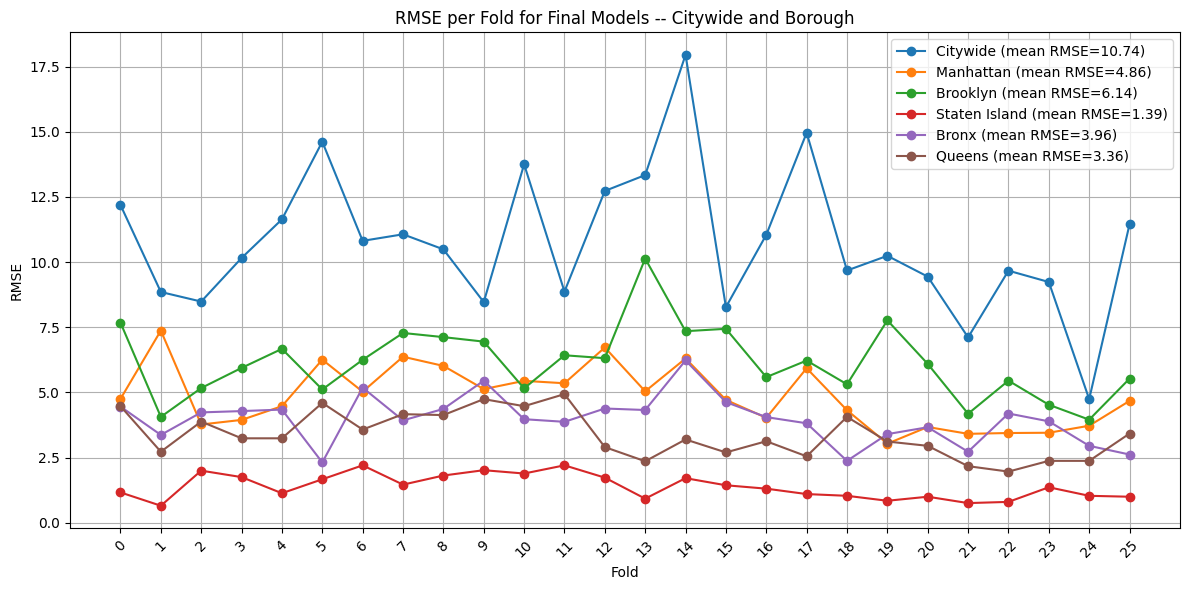

In [195]:
import matplotlib.pyplot as plt
import pandas as pd

results = {"Citywide": citywide_results, 
           "Manhattan": manhattan_results, 
           "Brooklyn": brooklyn_results,
           "Staten Island": staten_island_results, 
           "Bronx": bronx_results,
           "Queens": queens_results}

plt.figure(figsize=(12, 6))


# The shapes of the dataframe for citywide_results and {borough}_results differ so this code is clunkier than usual

for name, df in results.items():
    df_plot = df.copy()

    if 'rmse' in df_plot.columns:
        # Citywide: extract mean RMSE from 'mean' row
        if 'mean' in df_plot['fold'].values:
            mean_rmse = float(df_plot.loc[df_plot['fold'] == 'mean', 'rmse'])
            df_plot = df_plot[df_plot['fold'] != 'mean']  # drop mean row for plotting
        else:
            mean_rmse = df_plot['rmse'].mean()

        folds = df_plot['fold'].astype(str)
        rmse_values = df_plot['rmse']

    else:
        # Boroughs: mean row is an index
        if 'mean' in df_plot.index:
            mean_rmse = float(pd.to_numeric(df_plot.loc['mean'].values[0], errors='coerce'))
            df_plot = df_plot.loc[df_plot.index != 'mean']
        else:
            rmse_col = df_plot.columns[0]
            mean_rmse = pd.to_numeric(df_plot[rmse_col], errors='coerce').mean()

        # Convert RMSE to numeric, drop any NaNs
        rmse_col = df_plot.columns[0]
        df_plot[rmse_col] = pd.to_numeric(df_plot[rmse_col], errors='coerce')
        df_plot = df_plot.dropna()

        folds = df_plot.index.astype(str)
        rmse_values = df_plot[rmse_col]

    plt.plot(folds, rmse_values, marker='o', label=f"{name} (mean RMSE={mean_rmse:.2f})")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("RMSE per Fold for Final Models -- Citywide and Borough")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [196]:
import pandas as pd

rmse_data = {}

for name, df in results.items():
    df_plot = df.copy()
    
    if 'rmse' in df_plot.columns:
        df_plot = df_plot[df_plot['fold'] != 'mean']
        series = df_plot.set_index('fold')['rmse'].astype(float)
        series.index = series.index.astype(str)
    else:
        df_plot = df_plot.loc[df_plot.index != 'mean']
        rmse_col = df_plot.columns[0]
        series = pd.to_numeric(df_plot[rmse_col], errors='coerce').dropna()
        series.index = series.index.astype(str)

    rmse_data[name] = series

rmse_df = pd.DataFrame(rmse_data)
mean_row = rmse_df.mean(axis=0)
mean_row.name = 'mean'
rmse_df = pd.concat([rmse_df, mean_row.to_frame().T])
rmse_df = rmse_df.reset_index().rename(columns={'index': 'fold'})


rmse_df

,fold,Citywide,Manhattan,Brooklyn,Staten Island,Bronx,Queens
0,0,12.188988,4.750940,7.676495,1.164965,4.456135,4.472136
1,1,8.851957,7.372730,4.062019,0.654654,3.370036,2.725541
2,2,8.485281,3.770184,5.168586,2.000000,4.234214,3.882194
3,3,10.155927,3.946065,5.940178,1.752549,4.284524,3.240370
4,4,11.637378,4.472136,6.670832,1.133893,4.342481,3.240370
5,5,14.616527,6.256425,5.113009,1.669046,2.314550,4.598136
6,6,10.813352,5.028490,6.250714,2.203893,5.182388,3.575712
7,7,11.064745,6.369571,7.280110,1.463850,3.927922,4.166190
8,8,10.488088,6.017831,7.121396,1.812654,4.367085,4.131759
9,9,8.464210,5.126960,6.948792,2.017778,5.451081,4.743416
